Assignment2_Sweta_Chowdary.ipynb

Dataset: World Happiness Report (2011–2025)

1. Cover Page

2. Table of Contents

3. Import Libraries

4. Load Dataset

5. Part 1: Random Sampling Techniques and Sampling

6. Part 2: Confidence Intervals Using Bootstrapping

7. Part 3: QQ Plot and Long Tail Plot

8. Part 4: Comparison of Probability Distributions

9. Part 5: Student's t-Distribution and Applications

10. Conclusion

11. References

## Import Libraries

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import scipy.stats as stats

from scipy.stats import t

import seaborn as sns

## Load Data

In [53]:
df = pd.read_excel("WHR26_Data_Figure_2.1.xlsx")

df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## PART 1 Random Sampling Techniques and Sampling 
Select 100 samples (any attributes from the given dataset) using:
Tasks
• Simple Random Sampling
• Systematic Sampling
• Stratified Sampling (Use stratified sampling based on Year)
Deliverables
1. Explain possible biases
2. Write Python code with results of the above methods

## 1. Simple Random Sampling

In [54]:
simple_sample = df.sample(
    n=100,
    random_state=42
)

simple_sample.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
1618,2015,130,Mauritania,4.201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1471,2016,138,Zimbabwe,3.875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259,2024,113,Tunisia,4.552,4.470,4.633,1.257,1.224,0.459,0.382,0.032,0.050,1.149
432,2023,139,DR Congo,3.295,3.128,3.462,0.534,0.665,0.262,0.473,0.189,0.072,1.102
1506,2015,18,Belgium,6.929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Systematic Sampling

In [55]:
step = len(df)//100

systematic_sample = (
    df.iloc[::step]
      .head(100)
)

systematic_sample.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
21,2025,22,Saudi Arabia,6.817,6.726,6.907,1.949,1.412,0.831,1.042,0.096,0.196,1.291
42,2025,43,Malta,6.436,6.357,6.516,1.942,1.532,0.948,0.977,0.183,0.120,0.735
63,2025,64,Dominican Republic,6.093,5.957,6.230,1.664,1.406,0.702,1.015,0.061,0.188,1.057
84,2025,85,Greece,5.697,5.584,5.810,1.795,1.257,0.799,0.478,0.023,0.064,1.282


## 3. Stratified Sampling (Based on Year)

In [56]:
# Stratified Sampling - Proportional Allocation

stratified_list = []

for year in df['Year'].unique():
    year_data = df[df['Year'] == year]
    n = round(100 * len(year_data) / len(df))
    stratified_list.append(year_data.sample(n=n, random_state=42))

stratified_sample = pd.concat(stratified_list)
#stratified_sample = stratified_sample.sample(100, random_state=42)
stratified_sample.shape
stratified_sample

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
125,2025,126,Lesotho,4.375,4.170,4.579,1.007,1.135,0.000,0.741,0.057,0.069,1.365
51,2025,52,Thailand,6.296,6.187,6.405,1.632,1.424,0.694,1.087,0.195,0.029,1.234
138,2025,139,Egypt,3.862,3.765,3.958,1.558,0.862,0.521,0.727,0.022,0.097,0.074
19,2025,20,Czechia,6.821,6.739,6.903,1.869,1.594,0.720,1.045,0.106,0.081,1.405
104,2025,105,Tunisia,4.798,4.714,4.883,1.475,1.043,0.442,0.652,0.038,0.071,1.078
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2042,2011,83,Indonesia,5.159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2036,2011,77,Peru,5.258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2074,2011,115,Tajikistan,4.614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,2011,30,Germany,6.572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Part 1 Answers
Simple random sampling produced 100 observations but some years appeared more frequently than others.

Systematic sampling produced 100 observations selected at fixed intervals.

Stratified sampling produced a balanced sample by ensuring all years were represented.
### Possible Biases

### Simple Random Sampling : Every row in the World Happiness dataset had an equal chance of being selected. However, some years may be overrepresented or underrepresented by chance, which could affect how well the sample represents the entire period.

### Systematic Sampling: The sample was selected at regular intervals throughout the dataset. If the dataset is already sorted by year or another variable, systematic sampling may introduce bias because repeating patterns could influence the selected observations

### Stratified Sampling : Stratified sampling reduced bias because data from every year (2011–2025) was included in the sample. This method better represents changes in global happiness over time compared to the other sampling methods.

## PART 2 Confidence Intervals Using Bootstrapping

In [57]:
sample = df[
    'Life evaluation (3-year average)'
].sample(
    n=100,
    random_state=42
)

## Generate 1000 bootstrap samples

In [58]:
bootstrap_means = []

for i in range(1000):

    bootstrap_sample = sample.sample(
        n=100,
        replace=True
    )

    bootstrap_means.append(
        bootstrap_sample.mean()
    )

## Bootstrap CI

In [59]:
lower = np.percentile(
    bootstrap_means,
    2.5
)

upper = np.percentile(
    bootstrap_means,
    97.5
)

print(
    "95% Bootstrap CI:",
    lower,
    upper
)

95% Bootstrap CI: 5.1307775841007235 5.60977413566017


## Traditional CI

In [60]:
mean = sample.mean()

sem = (
    sample.std()
    /
    np.sqrt(
        len(sample)
    )
)

margin = 1.96 * sem

lower2 = mean - margin

upper2 = mean + margin

print(
    "Traditional CI:",
    lower2,
    upper2
)

Traditional CI: 5.121670215866331 5.608039797713989


### The bootstrap confidence interval and the traditional confidence interval are similar. Bootstrapping is more flexible because it does not assume a normal distribution.

## PART 3: QQ Plot and Long Tail Plot

In [61]:
attribute = 'Life evaluation (3-year average)'
data = df[attribute].dropna()

## Q1. Create 100 normal data points and draw a QQ-plot

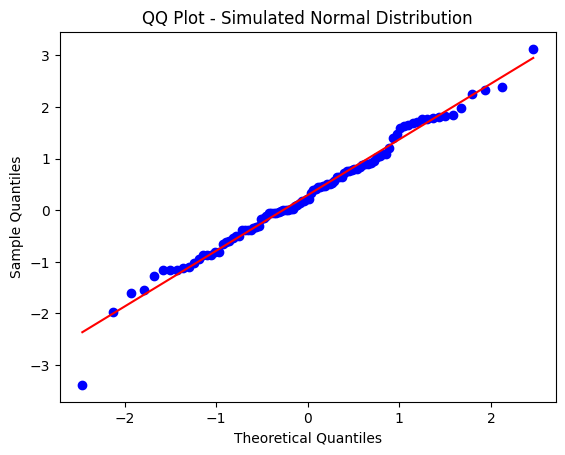

In [62]:
normal_data = np.random.normal(
    loc=0,
    scale=1,
    size=100
)

stats.probplot(
    normal_data,
    dist='norm',
    plot=plt
)

plt.title('QQ Plot - Simulated Normal Distribution')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.show()

## Q2. Draw QQ plot using dataset attribute

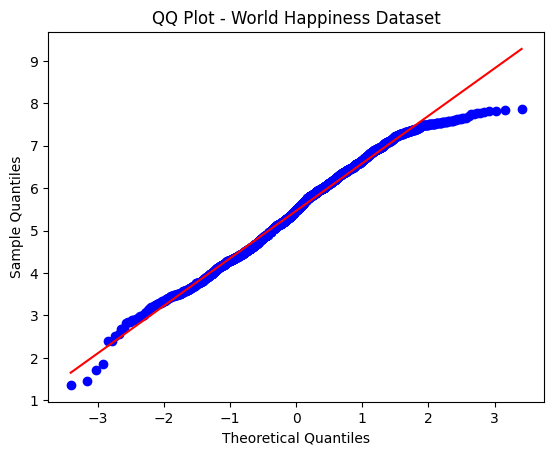

In [63]:
stats.probplot(
    data,
    dist='norm',
    plot=plt
)

plt.title('QQ Plot - World Happiness Dataset')

plt.xlabel('Theoretical Quantiles')

plt.ylabel('Sample Quantiles')

plt.show()

## Q3. Compare Q1 and Q2 

### The simulated normal data follows a straight line closely, indicating a normal distribution. The World Happiness data may deviate from the straight line, indicating slight skewness and that it is not perfectly normal.

## Q4. Add 10 extreme values to Q1 and draw a long-tail plot

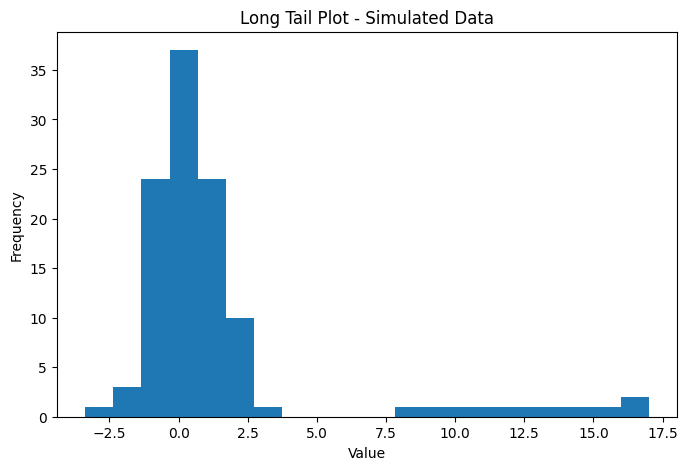

In [64]:
extreme_values = np.array([
    8,9,10,11,12,
    13,14,15,16,17
])

normal_with_outliers = np.concatenate([
    normal_data,
    extreme_values
])

plt.figure(figsize=(8,5))

plt.hist(
    normal_with_outliers,
    bins=20
)

plt.title('Long Tail Plot - Simulated Data')

plt.xlabel('Value')

plt.ylabel('Frequency')

plt.show()

## Q5. Add 10 extreme values to Q2 and draw long-tail plot

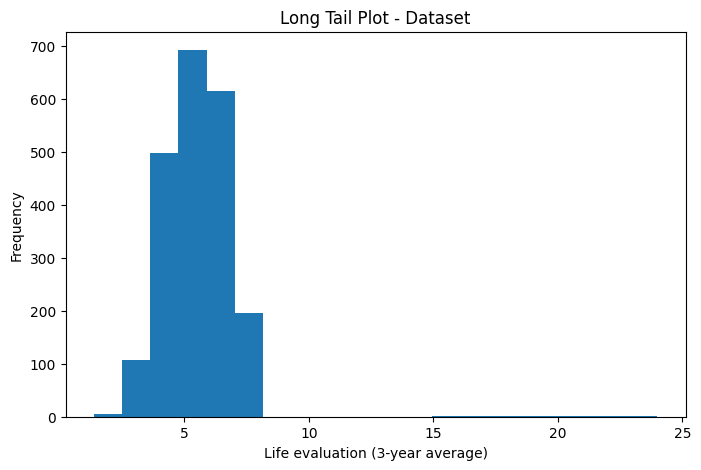

In [65]:
dataset_extreme = np.array([
    15,16,17,18,19,
    20,21,22,23,24
])

dataset_with_outliers = np.concatenate([
    data,
    dataset_extreme
])

plt.figure(figsize=(8,5))

plt.hist(
    dataset_with_outliers,
    bins=20
)

plt.title('Long Tail Plot - Dataset')

plt.xlabel(attribute)

plt.ylabel('Frequency')

plt.show()

## Q6. Compare Q4 and Q5

### Both plots show a longer right tail after adding extreme values. The dataset plot is more realistic because it originates from real-world data, whereas the simulated normal data was artificially generated.

## PART 4: Comparison of Probability Distributions

## 1. Normal Distribution

### Use the happiness scores.

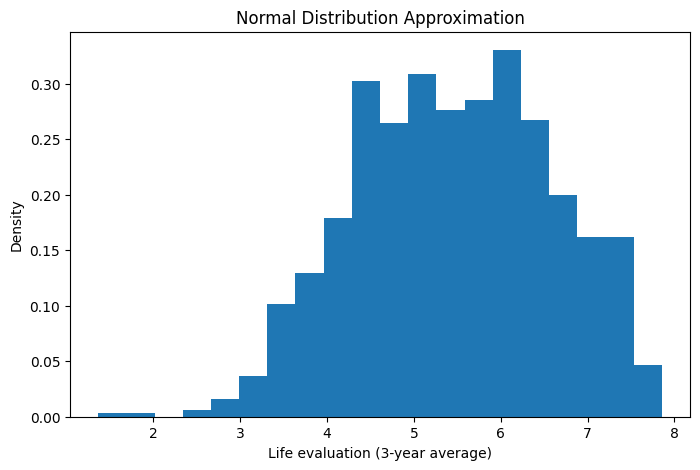

In [66]:
plt.figure(figsize=(8,5))

plt.hist(
    data,
    bins=20,
    density=True
)

plt.title('Normal Distribution Approximation')

plt.xlabel(attribute)

plt.ylabel('Density')

plt.show()

## 2. Binomial Distribution (simulated)

### Suppose:
### 20 trials
### 50% success probability

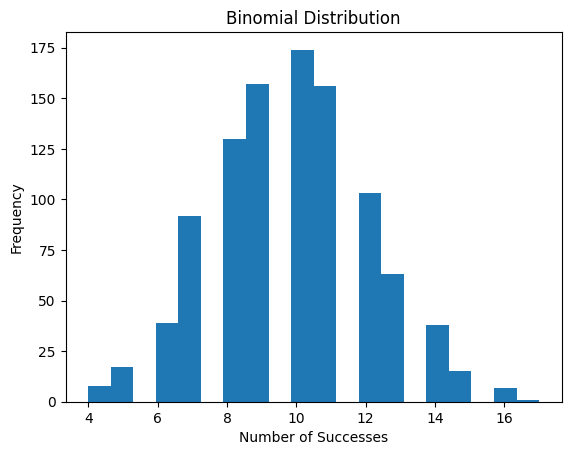

In [67]:
binomial_data = np.random.binomial(
    n=20,
    p=0.5,
    size=1000
)

plt.hist(
    binomial_data,
    bins=20
)

plt.title('Binomial Distribution')

plt.xlabel('Number of Successes')

plt.ylabel('Frequency')

plt.show()

## 3. Poisson Distribution (simulated)

### Suppose: Average λ = 5

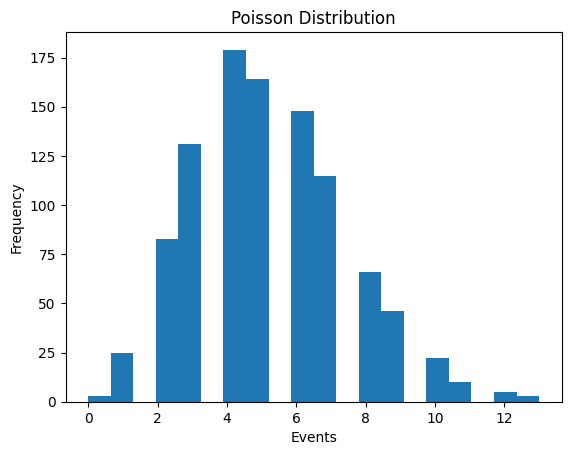

In [68]:
poisson_data = np.random.poisson(
    lam=5,
    size=1000
)

plt.hist(
    poisson_data,
    bins=20
)

plt.title('Poisson Distribution')

plt.xlabel('Events')

plt.ylabel('Frequency')

plt.show()

## Part 4 Comparison

### Normal Distribution: Suitable for continuous numerical data such as happiness scores. The World Happiness dataset closely follows a normal shape.

### Binomial Distribution: Suitable for binary outcomes such as success/failure experiments.

### Poisson Distribution: Suitable for counting the number of events occurring within a fixed interval.

### For the World Happiness dataset, the Normal distribution is the most appropriate because happiness scores are continuous numerical values rather than counts or binary outcomes.

## PART 5: Student's t-Distribution
### Compare df=5 and df=10

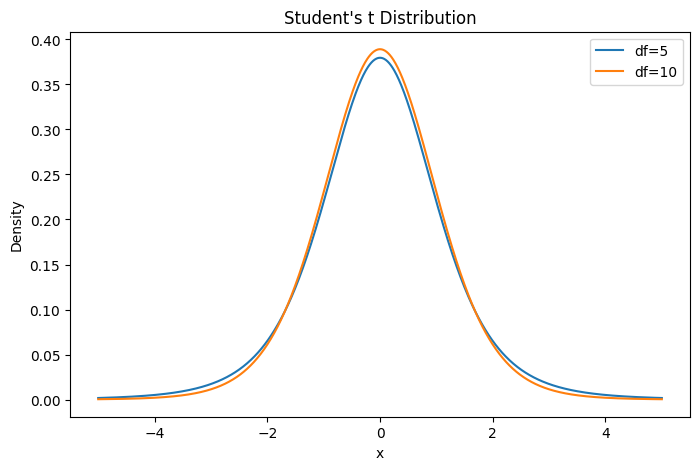

In [69]:
x = np.linspace(-5,5,1000)

y1 = t.pdf(
    x,
    df=5
)

y2 = t.pdf(
    x,
    df=10
)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    y1,
    label='df=5'
)

plt.plot(
    x,
    y2,
    label='df=10'
)

plt.title(
    "Student's t Distribution"
)

plt.xlabel('x')

plt.ylabel('Density')

plt.legend()

plt.show()

## Applications of t-distribution

1. Estimating population means when sample sizes are small.

2. Constructing confidence intervals.

3. Performing hypothesis testing.

4. Comparing sample means.

5. Used when the population standard deviation is unknown.

## Comparison

The t-distribution with 5 degrees of freedom has heavier tails and is more spread out.

The t-distribution with 10 degrees of freedom is narrower and begins to resemble the normal distribution.

As the degrees of freedom increase, the t-distribution approaches the normal distribution.

## Conclusion : This assignment explored various data science concepts using the World Happiness Report dataset. Different sampling techniques, confidence intervals, QQ-plots, probability distributions, and Student's t-distribution were applied. The analysis showed that the Normal distribution best represents happiness scores, while bootstrapping provides a flexible way to estimate confidence intervals. Overall, these techniques help understand real-world data and support statistical decision-making.

## References 

### 1. World Happiness Report Dataset:
https://www.worldhappiness.report/data-sharing/

### 2. NumPy Documentation:
https://numpy.org/doc/

### 3. Pandas Documentation:
https://pandas.pydata.org/docs/

### 4. SciPy Documentation:
https://docs.scipy.org/doc/scipy/

### 5. Matplotlib Documentation:
https://matplotlib.org/stable/

### 6. Course lecture notes and classroom material